In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

IMG_SIZE = (240, 240)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '/content/validate',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 603 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(240, 240, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/tmp/ipykernel_682/3563221605.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5340 - loss: 0.9251 - val_accuracy: 0.6667 - val_loss: 0.7201
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7280 - loss: 0.6102 - val_accuracy: 0.5889 - val_loss: 0.7447
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8076 - loss: 0.4843 - val_accuracy: 0.7778 - val_loss: 0.5531
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8458 - loss: 0.3970 - val_accuracy: 0.7667 - val_loss: 0.5395
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8872 - loss: 0.3198 - val_accuracy: 0.6778 - val_loss: 0.6555
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8690 - loss: 0.3360 - val_accuracy: 0.7778 - val_loss: 0.5072
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9254 - loss: 0.2523 - val_accuracy: 0.7333 - val_loss: 0.4895
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9254 - loss: 0.2275 - val_accuracy: 0.7556 - val_loss:

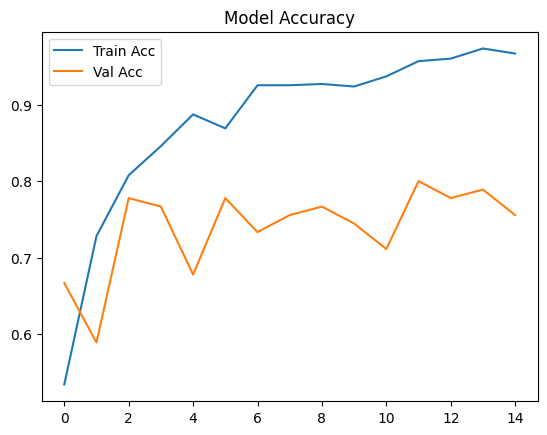

In [8]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

model.save('shoe_model.h5')

In [9]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model('shoe_model.h5')

loss, acc = loaded_model.evaluate(val_generator)
print(f"Validation Accuracy: {acc*100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7556 - loss: 0.5288
Validation Accuracy: 75.56%
